<a href="https://colab.research.google.com/github/davidshtengel/ds3001-final/blob/main/ML_Modeling_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks


In [116]:
np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')

# **Data Loading & Processing**

In [19]:
# load data
df = pd.read_csv('prepared_congress_trading_dataset.csv')

# Look at it
print(df.shape)
df.head()
print(df.columns.tolist())

(46349, 11)
['Unnamed: 0', 'Ticker', 'Traded', 'Transaction', 'Trade_Size_USD', 'Name', 'Filed', 'Party', 'District', 'Chamber', 'State']
Party
R    24457
D    21828
I       64
Name: count, dtype: int64


In [20]:
# Convert dates to datetime
df['Traded'] = pd.to_datetime(df['Traded'])
df['Filed'] = pd.to_datetime(df['Filed'])

# Days between trade and filing
df['Days_To_File'] = (df['Filed'] - df['Traded']).dt.days

# Month (1-12)
df['Month'] = df['Traded'].dt.month

# Year
df['Year'] = df['Traded'].dt.year

# Is it a purchase? 1=yes, 0=no
#print(df['Transaction'].value_counts())
df['Is_Purchase'] = (df['Transaction'] == 'Purchase').astype(int)

# Is it Senate? 1=yes, 0=no
df['Is_Senate'] = (df['Chamber'] == 'Senate').astype(int)

print(df[['Days_To_File', 'Month', 'Year', 'Is_Purchase', 'Is_Senate']].head())

Features created!
   Days_To_File  Month  Year  Is_Purchase  Is_Senate
0             2      3  2024            0          0
1             7      2  2024            0          0
2             7      2  2024            1          0
3             0      2  2024            1          0
4             8      2  2024            0          0


In [21]:
# Mapping trade sizes to numbers 0-9
size_map = {
    '$1-$1,000': 0,
    '$1,001 - $15,000': 1,
    '$15,001 - $50,000': 2,
    '$50,001 - $100,000': 3,
    '$100,001 - $250,000': 4,
    '$250,001 - $500,000': 5,
    '$500,001 - $1,000,000': 6,
    '$1,000,001 - $5,000,000': 7,
    '$5,000,001 - $25,000,000': 8,
    '$25,000,001 - $50,000,000': 9
}

df['Size_Number'] = df['Trade_Size_USD'].map(size_map)

print(df['Size_Number'].value_counts().sort_index())

Size_Number
0      453
1    34094
2     7612
3     2068
4     1452
5      372
6      173
7      103
8       19
9        3
Name: count, dtype: int64


In [36]:
# Get top 50 most common stocks
top_50 = df['Ticker'].value_counts().head(50).index.tolist()

df['Ticker_Simple'] = df['Ticker'].apply(lambda x: x if x in top_50 else 'Other')

# Make dummy columns (0 or 1 for each ticker)
ticker_dummies = pd.get_dummies(df['Ticker_Simple'], prefix='Ticker')
print(ticker_dummies.columns.tolist()[:10])

['Ticker_AAPL', 'Ticker_ABBV', 'Ticker_ACN', 'Ticker_AMZN', 'Ticker_BA', 'Ticker_BABA', 'Ticker_BAC', 'Ticker_BRK.B', 'Ticker_CMCSA', 'Ticker_COST']


In [37]:
# combine all features
X = pd.concat([
    df[['Days_To_File', 'Month', 'Is_Purchase', 'Is_Senate', 'Size_Number']],
    ticker_dummies
], axis=1)

* **Days_To_File** – How fast they report
* **Month** – Seasonal patterns
* **Year** – Time trends
* **Is_Purchase** – Buying vs selling
* **Is_Senate** – House vs Senate
* **Size_Number** – How much they trade
* **Ticker_AAPL, Ticker_MSFT, etc**. – What stocks they pick



In [38]:
#: 1=Republican, 0=Democrat
y = (df['Party'] == 'R').astype(int)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Total features: {X.shape[1]}")

X shape: (45945, 56)
y shape: (45945,)
Total features: 56


In [40]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {len(X_train)} trades")
print(f"Testing: {len(X_test)} trades")


Training: 36756 trades
Testing: 9189 trades


**Logistic Regression (Baseline model)**

In [43]:
# train
LR_model = LogisticRegression(max_iter=1000, random_state=42)
LR_model.fit(X_train_scaled, y_train)
# test
LR_predictions = LR_model.predict(X_test_scaled)
LR_accuracy = accuracy_score(y_test, LR_predictions)

In [46]:

print(f"Accuracy: {LR_accuracy:.2%}")
print("\n", classification_report(y_test, LR_predictions, target_names=['Democrat', 'Republican']))


Accuracy: 64.09%

               precision    recall  f1-score   support

    Democrat       0.60      0.75      0.66      4348
  Republican       0.71      0.54      0.62      4841

    accuracy                           0.64      9189
   macro avg       0.65      0.65      0.64      9189
weighted avg       0.65      0.64      0.64      9189



**Random Forest**

In [107]:
# Test with different max_depth values
depths = [5, 10, 15, 20, None]
results = []

print("Testing Different Random Forest Depths:")

for depth in depths:
    RF_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    RF_model.fit(X_train, y_train)

    train_acc = RF_model.score(X_train, y_train)
    test_acc = RF_model.score(X_test, y_test)
    gap = train_acc - test_acc

    results.append({
        'max_depth': depth if depth else 'None',
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap': gap
    })

    depth_str = str(depth) if depth else 'None'
    print(f"max_depth={depth_str:5s} Train: {train_acc:.2%}  Test: {test_acc:.2%} Gap: {gap:.2%}")

Testing Different Random Forest Depths:
max_depth=5     Train: 65.71%  Test: 65.24% Gap: 0.47%
max_depth=10    Train: 68.38%  Test: 66.88% Gap: 1.49%
max_depth=15    Train: 74.57%  Test: 70.82% Gap: 3.75%
max_depth=20    Train: 81.17%  Test: 74.35% Gap: 6.82%
max_depth=None  Train: 87.89%  Test: 76.46% Gap: 11.43%


In [88]:
depth_labels = [str(r['max_depth']) for r in results]
train_accs = [r['train_acc'] for r in results]
test_accs  = [r['test_acc'] for r in results]
gap_accs   = [r['gap'] for r in results]

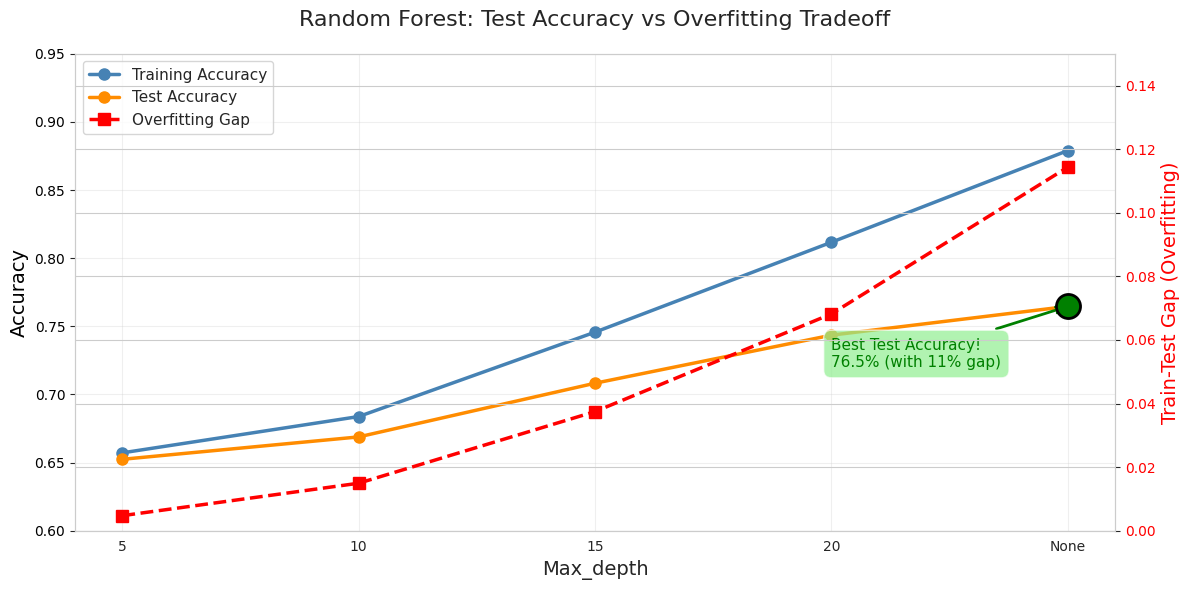

In [89]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis: Accuracy
ax1.plot(depth_labels, train_accs, marker='o', linewidth=2.5,
         markersize=8, color='steelblue', label='Training Accuracy')
ax1.plot(depth_labels, test_accs, marker='o', linewidth=2.5,
         markersize=8, color='darkorange', label='Test Accuracy')
ax1.set_xlabel('Max_depth', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0.6, 0.95)
ax1.grid(True, alpha=0.3)

# Right y-axis: Overfitting Gap
ax2 = ax1.twinx()
ax2.plot(depth_labels, gap_accs, marker='s', linewidth=2.5,
         markersize=8, color='red', linestyle='--', label='Overfitting Gap')
ax2.set_ylabel('Train-Test Gap (Overfitting)', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 0.15)

# highlight the best test accuracy
best_idx = test_accs.index(max(test_accs))
ax1.scatter(best_idx, max(test_accs), color='green', s=300,
            zorder=5, edgecolor='black', linewidth=2)

# add title and legends (combine them)
plt.title('Random Forest: Test Accuracy vs Overfitting Tradeoff',
          fontsize=16, pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax1.annotate('Best Test Accuracy!\n76.5% (with 11% gap)',
             xy=(best_idx, max(test_accs)),
             xytext=(best_idx-1, 0.72),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=11, color='green',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

We tested multiple Random Forest depths to balance model complexity and generalization. As tree depth increased, the model captured more complex relationships and test accuracy improved, peaking at 76.5% with unlimited depth, though this came with a larger overfitting gap of about 11%.

**Neural Networks**

In [54]:
nn_results = {}

In [58]:
# Architecture 1: Baseline (Prof said to start here)
nn1 = keras.Sequential([
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

nn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn1.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

loss1, accuracy_nn1 = nn1.evaluate(X_test_scaled, y_test, verbose=0)

nn_results['64-32'] = accuracy_nn1
print(f"Accuracy: {accuracy_nn1:.2%}")

Epoch 1/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5828 - loss: 0.6859
Epoch 2/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6355 - loss: 0.6447
Epoch 3/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6405 - loss: 0.6376
Epoch 4/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6441 - loss: 0.6326
Epoch 5/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6442 - loss: 0.6303
Epoch 6/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6466 - loss: 0.6300
Epoch 7/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6459 - loss: 0.6248
Epoch 8/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6489 - loss: 0.6237
Epoch 9/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6494 - loss: 0.6227
Epoch 10/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6489 - loss: 0.6215
Epoch 11/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6520 - loss: 0.6190
Epoch 12/50
1149/1149 ━━━━━━━

In [59]:
# Architecture 2: Wider (128-64-32)
nn2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

nn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn2.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

loss2, accuracy_nn2 = nn1.evaluate(X_test_scaled, y_test, verbose=0)

nn_results['128-64-32'] = accuracy_nn2
print(f"Accuracy: {accuracy_nn2:.2%}")

Epoch 1/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6003 - loss: 0.6786
Epoch 2/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6342 - loss: 0.6446
Epoch 3/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6416 - loss: 0.6363
Epoch 4/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6474 - loss: 0.6294
Epoch 5/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6462 - loss: 0.6264
Epoch 6/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6509 - loss: 0.6231
Epoch 7/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6500 - loss: 0.6197
Epoch 8/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6512 - loss: 0.6187
Epoch 9/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6525 - loss: 0.6173
Epoch 10/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6529 - loss: 0.6148
Epoch 11/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6551 - loss: 0.6117
Epoch 12/50
1149/1149 ━━━━━━━

In [60]:
# Architecture 3: Narrower (32-16)
nn3 = keras.Sequential([
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
nn3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn3.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)

loss3, accuracy_nn3 = nn3.evaluate(X_test_scaled, y_test, verbose=0)
nn_results['32-16'] = accuracy_nn3

print(f"Accuracy: {accuracy_nn3:.2%}")


Accuracy: 65.27%


In [61]:
# architecture 4: deeper
nn4 = keras.Sequential([
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
nn4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn4.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)

loss4, accuracy_nn4 = nn4.evaluate(X_test_scaled, y_test, verbose=0)
nn_results['64-64-32-16'] = accuracy_nn4

print(f"Accuracy: {accuracy_nn4:.2%}")

Accuracy: 66.34%


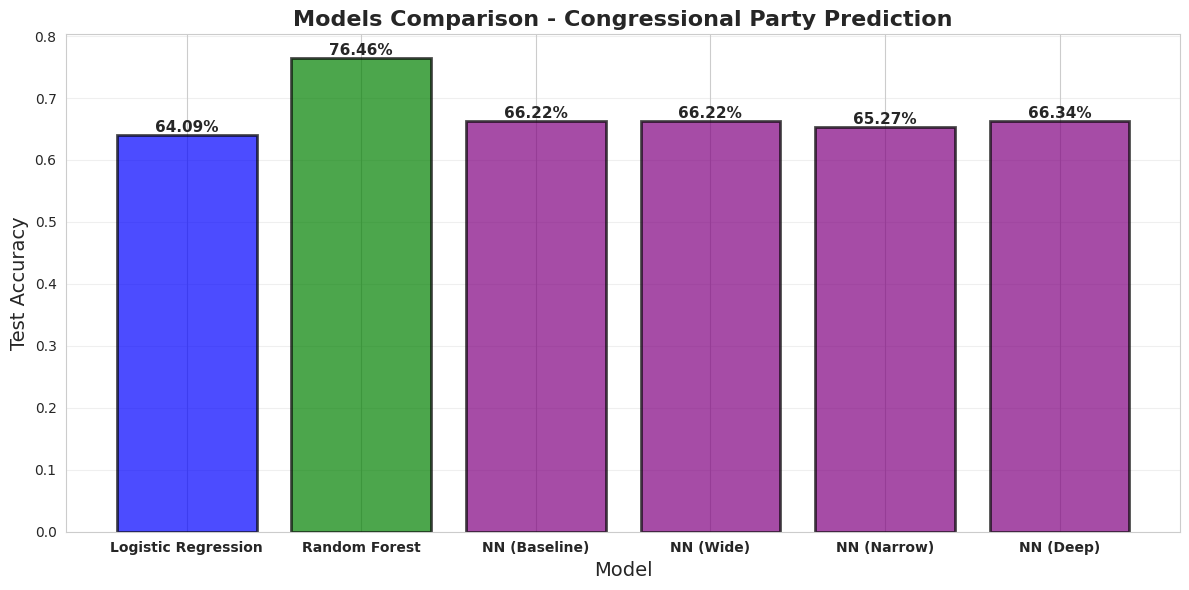

In [106]:
# plot all results
all_results = {
    'Logistic Regression': 0.6409,
    'Random Forest': 0.7646,  # Your best RF
    'NN (Baseline)': nn_results['64-32'],
    'NN (Wide)': nn_results['128-64-32'],
    'NN (Narrow)': nn_results['32-16'],
    'NN (Deep)': nn_results['64-64-32-16']
}

plt.figure(figsize=(12, 6))
models = list(all_results.keys())
accs = list(all_results.values())
# color code
colors = ['blue', 'green', 'purple', 'purple', 'purple', 'purple']
bars = plt.bar(models, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, acc in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Model', fontsize=14)
plt.ylabel('Test Accuracy', fontsize=14)
plt.xticks(fontweight='bold')
plt.title('Models Comparison - Congressional Party Prediction', fontsize=16, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [113]:
# Feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RF_model.feature_importances_
}).sort_values('Importance', ascending=False)

importances.head(10)

,Feature,Importance
0,Days_To_File,0.475694
1,Month,0.199315
3,Is_Senate,0.093249
4,Size_Number,0.082678
2,Is_Purchase,0.018634
37,Ticker_Other,0.012519
33,Ticker_MSFT,0.006739
5,Ticker_AAPL,0.005241
18,Ticker_DIS,0.003374
8,Ticker_AMZN,0.003306


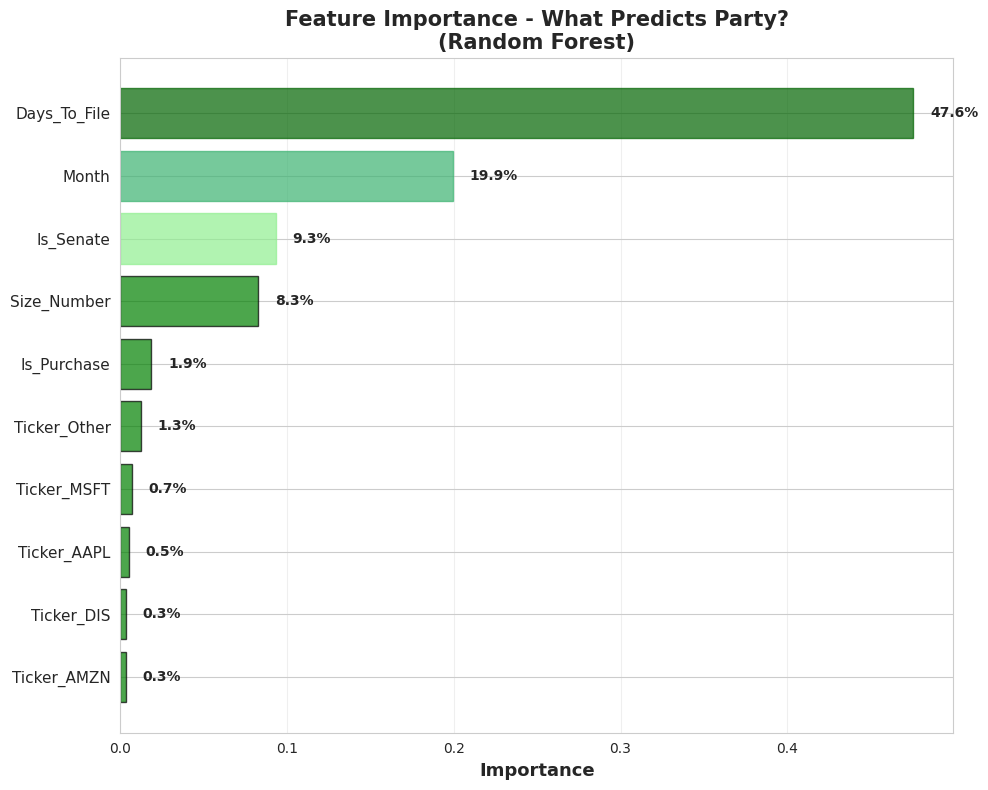

In [115]:
top_10 = importances.head(10)
# create plot
plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(top_10)), top_10['Importance'], color='green', alpha=0.7, edgecolor='black')
# Days_To_File
bars[0].set_color('darkgreen')
# Month
bars[1].set_color('mediumseagreen')
# Is_Senate
bars[2].set_color('lightgreen')
plt.yticks(range(len(top_10)), top_10['Feature'], fontsize=11)
plt.xlabel('Importance', fontsize=13, fontweight='bold')
plt.title('Feature Importance - What Predicts Party?\n(Random Forest)', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', alpha=0.3)
# add labels
for i, (bar, importance) in enumerate(zip(bars, top_10['Importance'])):
    plt.text(importance + 0.01, i, f'{importance:.1%}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Because our model was trained at the level of individual trades rather than aggregated by legislator, the strongest predictive signals reflect per-trade behavioral and disclosure patterns rather than long-term investment strategy. As a result, features such as reporting delay and timing dominate the model’s feature importance, while individual stock selections contribute relatively little.